In [ ]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Base directory
path = r"dataset/synthetic_dataset/synthetic_mobile_money_transaction_dataset.csv"

df = pd.read_csv(path)
print("Shape : " , df.shape)
df.head()

Shape :  (1720181, 10)


,step,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud
0,0,TRANSFER,19824.96,4537027967639631,187712.18,167887.22,4875702729424478,8.31,19833.27,1
1,0,PAYMENT,598.97,4296267625767470,8.92,8.92,25-0000401,0.00,0.00,0
2,0,PAYMENT,545.85,4178224023847746,93.60,-452.25,13-0001587,0.00,545.85,0
3,0,TRANSFER,19847.01,4178224023847746,-452.25,-20299.26,4096920916696293,4011.72,23858.74,1
4,0,PAYMENT,546.89,4779013371563747,159148.76,158601.88,75-0003564,0.00,546.89,0


In [5]:
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1720181 entries, 0 to 1720180
Data columns (total 10 columns):
 #   Column           Dtype  
---  ------           -----  
 0   step             int64  
 1   transactionType  object 
 2   amount           float64
 3   initiator        int64  
 4   oldBalInitiator  float64
 5   newBalInitiator  float64
 6   recipient        object 
 7   oldBalRecipient  float64
 8   newBalRecipient  float64
 9   isFraud          int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 131.2+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,1720181.0,NaN,NaN,NaN,65.555286,44.673684,0.0,23.0,54.0,106.0,143.0
transactionType,1720181,5,PAYMENT,667245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,1720181.0,NaN,NaN,NaN,52538.679612,88356.497983,0.24,606.46,17298.25,71161.49,2142928.28
initiator,1720181.0,NaN,NaN,NaN,4499951976758673.0,289635131225563.0,4000061963235266.0,4248761574606837.0,4508521162599660.0,4750928280020948.0,4999855045426980.0
oldBalInitiator,1720181.0,NaN,NaN,NaN,2433757.597989,1307614.874018,-199997.11,1577186.32,2619827.17,3361338.4,12244691.62
newBalInitiator,1720181.0,NaN,NaN,NaN,2443879.729006,1297180.529754,-199997.11,1600495.69,2625680.49,3361871.54,12244691.62
recipient,1720181,16731,56-0008969,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldBalRecipient,1720181.0,NaN,NaN,NaN,108508.328753,283013.771027,-198368.47,16064.23,63130.18,137382.17,11885539.37
newBalRecipient,1720181.0,NaN,NaN,NaN,122277.215395,319227.67989,-135727.98,24962.33,74481.61,143170.24,12066212.12
isFraud,1720181.0,NaN,NaN,NaN,0.102035,0.302694,0.0,0.0,0.0,0.0,1.0


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
step,1720181.0,6.555529e+01,4.467368e+01,0.000000e+00,2.300000e+01,5.400000e+01,1.060000e+02,1.430000e+02
amount,1720181.0,5.253868e+04,8.835650e+04,2.400000e-01,6.064600e+02,1.729825e+04,7.116149e+04,2.142928e+06
initiator,1720181.0,4.499952e+15,2.896351e+14,4.000062e+15,4.248762e+15,4.508521e+15,4.750928e+15,4.999855e+15
oldBalInitiator,1720181.0,2.433758e+06,1.307615e+06,-1.999971e+05,1.577186e+06,2.619827e+06,3.361338e+06,1.224469e+07
newBalInitiator,1720181.0,2.443880e+06,1.297181e+06,-1.999971e+05,1.600496e+06,2.625680e+06,3.361872e+06,1.224469e+07
oldBalRecipient,1720181.0,1.085083e+05,2.830138e+05,-1.983685e+05,1.606423e+04,6.313018e+04,1.373822e+05,1.188554e+07
newBalRecipient,1720181.0,1.222772e+05,3.192277e+05,-1.357280e+05,2.496233e+04,7.448161e+04,1.431702e+05,1.206621e+07
isFraud,1720181.0,1.020346e-01,3.026939e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


In [7]:
missing_rate = df.isna().mean()
missing_rate = missing_rate.sort_values(ascending=False)
missing_rate.head(13)

step               0.0
transactionType    0.0
amount             0.0
initiator          0.0
oldBalInitiator    0.0
newBalInitiator    0.0
recipient          0.0
oldBalRecipient    0.0
newBalRecipient    0.0
isFraud            0.0
dtype: float64

In [8]:
step_count = df["step"].nunique()
print("Total hours : " , step_count)

Total hours :  144


In [9]:
initiator_count = df["initiator"].nunique()
recipients_count = df["recipient"].nunique()

print(f"Unique customers: {initiator_count}")
print(f"Unique recipients: {recipients_count}")

Unique customers: 13462
Unique recipients: 16731


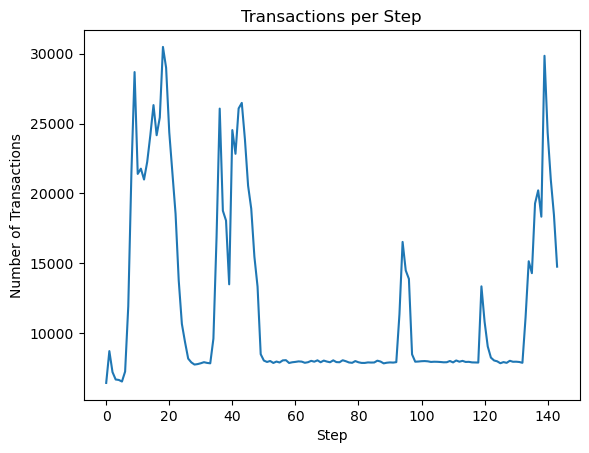

In [10]:
tx_per_step = df["step"].value_counts().sort_index()

tx_per_step.plot()
plt.title("Transactions per Step")
plt.xlabel("Step")
plt.ylabel("Number of Transactions")
plt.show()

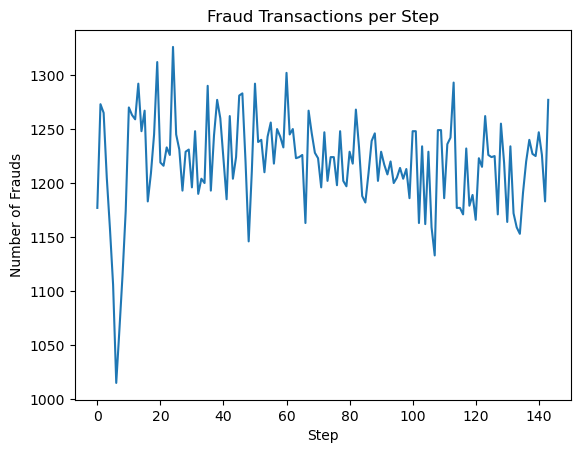

In [11]:
fraud_per_step = df.groupby("step")["isFraud"].sum()

fraud_per_step.plot()
plt.title("Fraud Transactions per Step")
plt.xlabel("Step")
plt.ylabel("Number of Frauds")
plt.show()

In [12]:
print("Counts : " , df["isFraud"].value_counts())
df["isFraud"].value_counts(normalize=True)

Counts :  isFraud
0    1544663
1     175518
Name: count, dtype: int64


isFraud
0    0.897965
1    0.102035
Name: proportion, dtype: float64

In [13]:
# df["balance_error"] = df["newBalInitiator"] - (df["oldBalInitiator"] - df["amount"])
# df["balance_error"].describe()

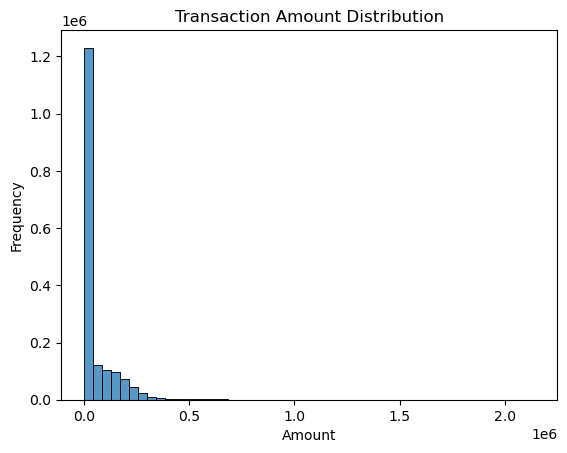

In [14]:
sns.histplot(df["amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

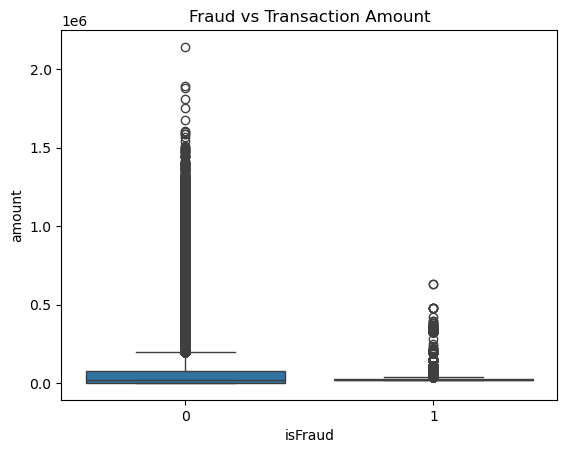

In [15]:
sns.boxplot(x="isFraud", y="amount", data=df)
plt.title("Fraud vs Transaction Amount")
plt.show()

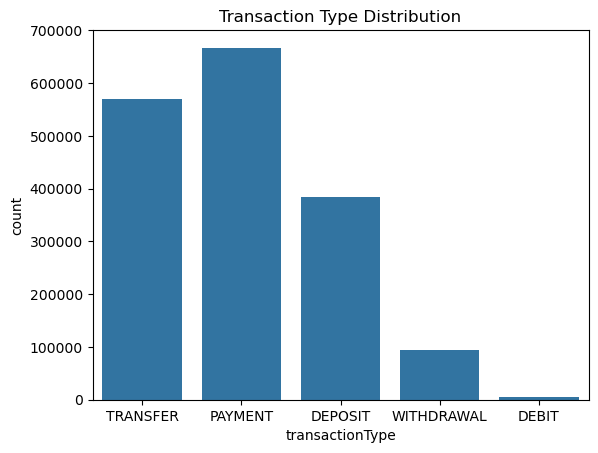

In [16]:
sns.countplot(x="transactionType", data=df)
plt.title("Transaction Type Distribution")
plt.xticks()
plt.show()

isFraud                0        1
transactionType                  
DEBIT            1.00000  0.00000
DEPOSIT          1.00000  0.00000
PAYMENT          1.00000  0.00000
TRANSFER         0.69171  0.30829
WITHDRAWAL       1.00000  0.00000


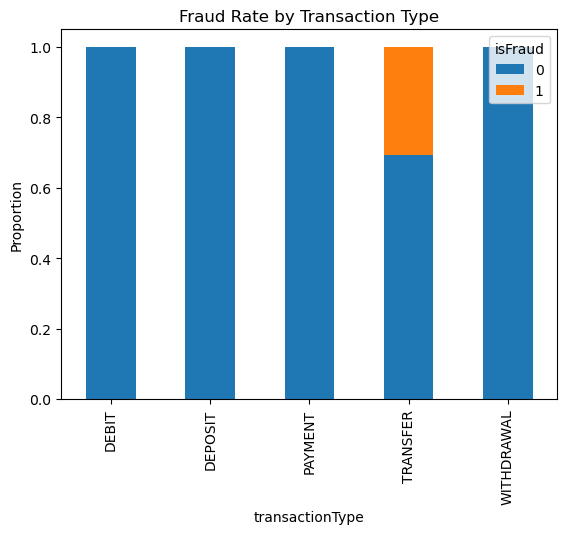

In [17]:
fraud_types = pd.crosstab(
    df["transactionType"],
    df["isFraud"],
    normalize="index"
)

print(fraud_types)

fraud_types.plot(kind="bar", stacked=True)
plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Proportion")
plt.show()

In [18]:
fraud_transfer = df[
    (df["isFraud"] == 1) &
    (df["transactionType"] == "TRANSFER")
]

print(len(fraud_transfer))

175518


In [19]:
print("Negative oldBalInitiator:",
      (df["oldBalInitiator"] < 0).sum())

print("Negative newBalInitiator:",
      (df["newBalInitiator"] < 0).sum())

print("Negative oldBalRecipient:",
      (df["oldBalRecipient"] < 0).sum())

print("Negative oldBalRecipient:",
      (df["newBalRecipient"] < 0).sum())

Negative oldBalInitiator: 44402
Negative newBalInitiator: 44621
Negative oldBalRecipient: 117
Negative oldBalRecipient: 15


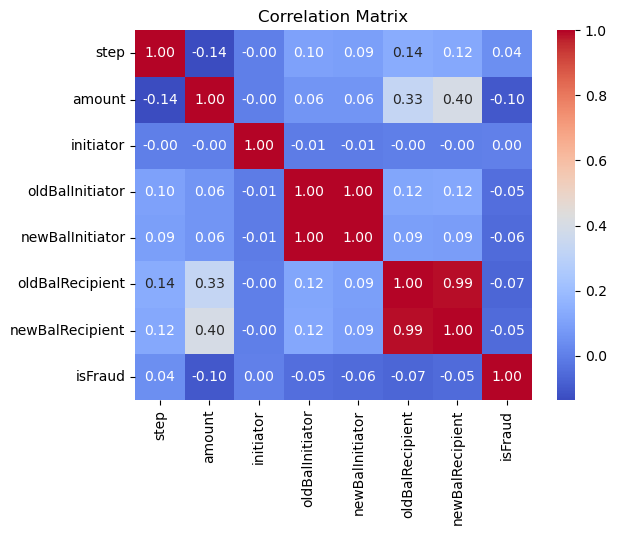

In [20]:
correlation_map = df.corr(numeric_only=True)

sns.heatmap(correlation_map, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [21]:
df["balance_error_i"] = df["newBalInitiator"] - (df["oldBalInitiator"] - df["amount"])
df["balance_error_r"] = df["newBalRecipient"] - (df["oldBalRecipient"] + df["amount"])

df_error_i = df[
    (df["balance_error_i"].abs() > 1e-6)
]

df_error_r = df[
    (df["balance_error_r"].abs() > 1e-6)
]

error_i_fraud = (df_error_i["isFraud"] == 1).sum()
error_r_fraud = (df_error_r["isFraud"] == 1).sum()

print("Balance mismatch (initiator) : " , len(df_error_i))
print("Fraud count :", error_i_fraud)

print("Balance mismatch (recipient) : " , len(df_error_r))
print("Fraud count :", error_r_fraud)

Balance mismatch (initiator) :  759832
Fraud count : 52778
Balance mismatch (recipient) :  784452
Fraud count : 38200


In [22]:
df_negbal = df[
    (df["oldBalInitiator"] < 0) |
	(df["newBalInitiator"] < 0) |
	(df["oldBalRecipient"] < 0) |
	(df["newBalRecipient"] < 0)
]

fraud_negbal = (df_negbal["isFraud"] == 1).sum()
total_negbal = len(df_negbal)

print("Total negative balance transactions:", total_negbal)
print("Fraud count in suspicious:", fraud_negbal)

Total negative balance transactions: 48213
Fraud count in suspicious: 6170


In [ ]:
cols = [
    "oldBalInitiator",
    "newBalInitiator",
    "oldBalRecipient",
    "newBalRecipient"
]

summary = []

for col in cols:
    neg_rows = df[df[col] < 0]
    
    total_neg = len(neg_rows)
    fraud_neg = neg_rows["isFraud"].sum()
    legit_neg = total_neg - fraud_neg
    
    summary.append({
        "feature": col,
        "total_negative": total_neg,
        "fraud_count": fraud_neg,
        "legit_count": legit_neg
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

           feature  total_negative  fraud_count  legit_count
0  oldBalInitiator           44402         5649        38753
1  newBalInitiator           44621         6170        38451
2  oldBalRecipient             117            0          117
3  newBalRecipient              15            0           15


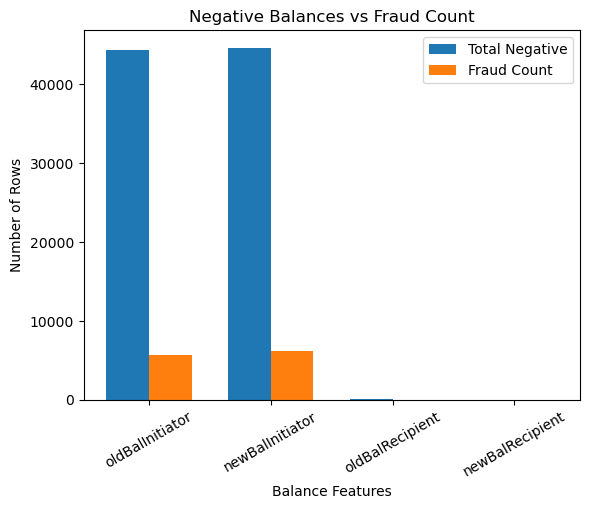

In [24]:
x = np.arange(len(summary_df["feature"]))
width = 0.35

plt.figure()

plt.bar(x - width/2, summary_df["total_negative"], width, label="Total Negative")
plt.bar(x + width/2, summary_df["fraud_count"], width, label="Fraud Count")

plt.xticks(x, summary_df["feature"], rotation=30)
plt.xlabel("Balance Features")
plt.ylabel("Number of Rows")
plt.title("Negative Balances vs Fraud Count")

plt.legend()

plt.show()

In [25]:
df.groupby("step").size().describe()

count      144.000000
mean     11945.701389
std       6488.038875
min       6407.000000
25%       7887.000000
50%       7975.500000
75%      14836.750000
max      30489.000000
dtype: float64

In [27]:
df_fraud = df[df["isFraud"] == 1].copy()

print("Fraud dataset shape:", df_fraud.shape)
df_fraud.head(10)

Fraud dataset shape: (175518, 12)


,step,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud,balance_error_i,balance_error_r
0,0,TRANSFER,19824.96,4537027967639631,187712.18,167887.22,4875702729424478,8.31,19833.27,1,0.000000e+00,0.00
3,0,TRANSFER,19847.01,4178224023847746,-452.25,-20299.26,4096920916696293,4011.72,23858.74,1,0.000000e+00,0.01
5,0,TRANSFER,16973.75,4779013371563747,158601.88,141628.12,4593247015015219,54.33,17028.08,1,-1.000000e-02,0.00
7,0,TRANSFER,21103.99,4479448076398077,261291.46,240187.47,4649550475321678,19.63,21123.63,1,0.000000e+00,0.01
9,0,TRANSFER,16908.07,4587942659105635,4160.05,4160.05,4863167876028593,66.12,66.12,1,1.690807e+04,-16908.07
11,0,TRANSFER,23715.64,4978866660478516,77826.87,54111.24,4822936618475944,14691.67,38407.31,1,1.000000e-02,0.00
20,0,TRANSFER,18533.84,4781213214714848,23562.49,5028.65,4663047917704976,68.34,18602.18,1,-1.818989e-12,0.00
25,0,TRANSFER,21966.03,4120037473988300,318503.12,296537.08,4187906273321880,26.32,21992.36,1,-1.000000e-02,0.01
28,0,TRANSFER,74145.41,4223078546024950,-632.85,-632.85,4840197438076267,11.96,11.96,1,7.414541e+04,-74145.41
30,0,TRANSFER,23981.81,4799013284929379,19240.28,19240.28,4792446526809487,2020.97,2020.97,1,2.398181e+04,-23981.81


In [28]:
df_nonfraud = df[df["isFraud"] == 0].copy()

print("Non-Fraud dataset shape:", df_nonfraud.shape)
df_nonfraud.head(10)

Non-Fraud dataset shape: (1544663, 12)


,step,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud,balance_error_i,balance_error_r
1,0,PAYMENT,598.97,4296267625767470,8.92,8.92,25-0000401,0.00,0.00,0,5.989700e+02,-5.989700e+02
2,0,PAYMENT,545.85,4178224023847746,93.60,-452.25,13-0001587,0.00,545.85,0,0.000000e+00,0.000000e+00
4,0,PAYMENT,546.89,4779013371563747,159148.76,158601.88,75-0003564,0.00,546.89,0,1.000000e-02,0.000000e+00
6,0,PAYMENT,659.02,4479448076398077,261950.48,261291.46,11-0003866,0.00,659.02,0,-2.910383e-11,0.000000e+00
8,0,PAYMENT,648.89,4587942659105635,4808.94,4160.05,64-0008405,0.00,648.89,0,9.094947e-13,0.000000e+00
10,0,PAYMENT,586.53,4978866660478516,78413.40,77826.87,48-0008930,0.00,586.53,0,0.000000e+00,0.000000e+00
12,0,PAYMENT,495.68,4801014238577179,45.50,45.50,37-0004271,0.00,0.00,0,4.956800e+02,-4.956800e+02
13,0,PAYMENT,620.50,4488893430580853,10.72,-609.77,91-0008198,0.00,620.50,0,1.000000e-02,0.000000e+00
14,0,TRANSFER,19665.08,4488893430580853,-609.77,-20274.86,4622593723010843,90.11,19755.19,0,-1.000000e-02,-3.637979e-12
15,0,PAYMENT,540.54,4901579220413913,18.32,18.32,39-0003317,0.00,0.00,0,5.405400e+02,-5.405400e+02


C:\Users\edward wibowo\AppData\Local\Temp\ipykernel_20780\1737480278.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='isFraud', y='amount', data=df, palette='Set2')


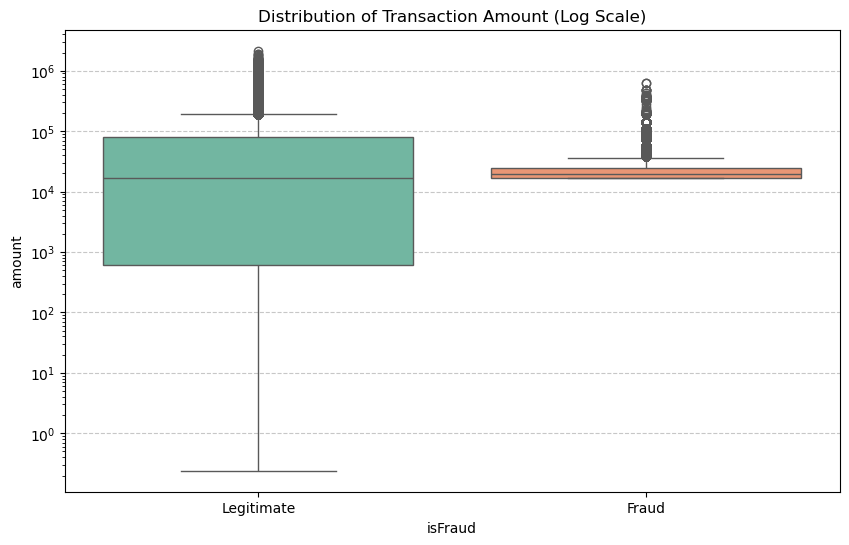

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Amount Distribution - Boxplot with Log Scale
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='amount', data=df, palette='Set2')
plt.yscale('log')
plt.title('Distribution of Transaction Amount (Log Scale)')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

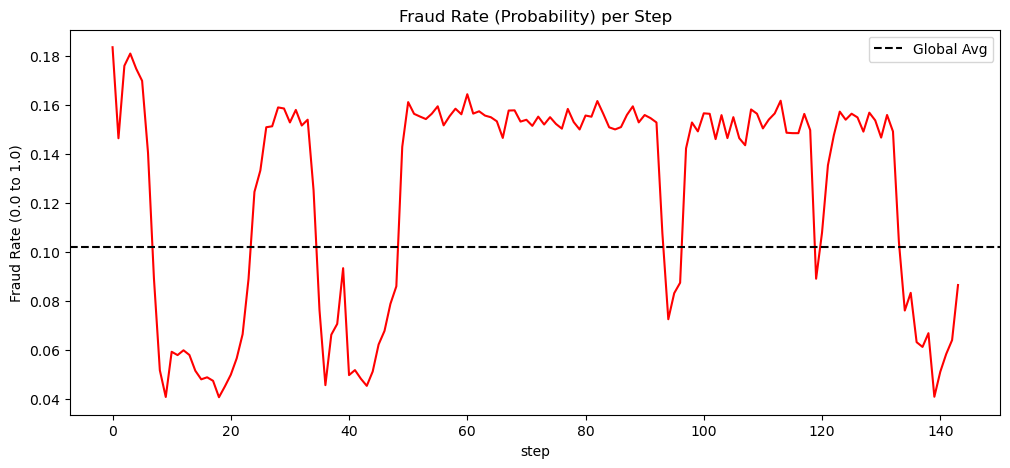

In [30]:
# Calculate fraud rate per step
step_stats = df.groupby('step')['isFraud'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=step_stats, x='step', y='isFraud', color='red')
plt.title('Fraud Rate (Probability) per Step')
plt.ylabel('Fraud Rate (0.0 to 1.0)')
plt.axhline(df['isFraud'].mean(), color='black', linestyle='--', label='Global Avg')
plt.legend()
plt.show()

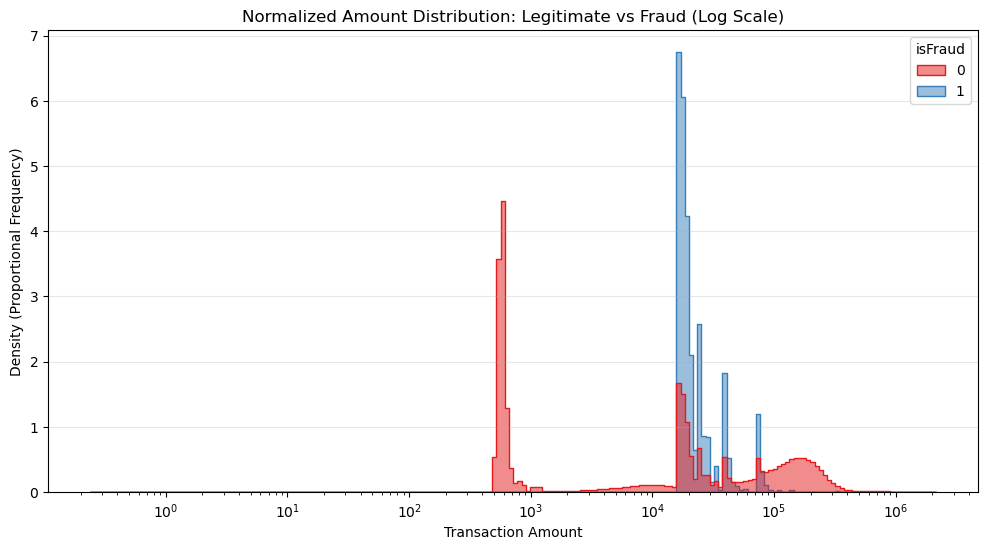

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# 'stat=density' and 'common_norm=False'
# Compare the relative frequency of fraud vs legitimate
sns.histplot(data=df, x='amount', hue='isFraud', 
             element='step', stat='density', common_norm=False, 
             log_scale=True, palette='Set1', alpha=0.5)

plt.title('Normalized Amount Distribution: Legitimate vs Fraud (Log Scale)')
plt.xlabel('Transaction Amount')
plt.ylabel('Density (Proportional Frequency)')
plt.grid(axis='y', alpha=0.3)
plt.show()

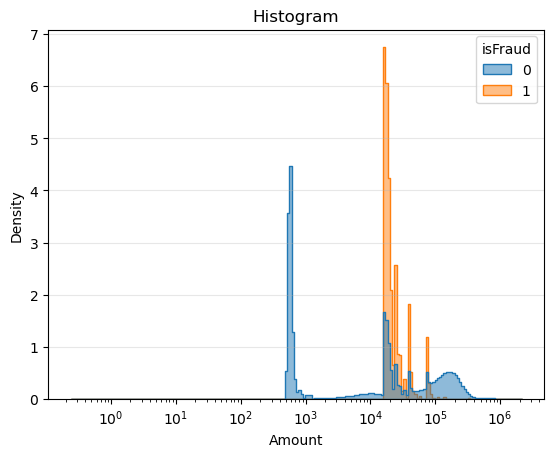

In [33]:
plt.figure()
sns.histplot(data=df , x='amount' , stat='density' , alpha=0.5 , log_scale=True , hue='isFraud' , element='step' , common_norm=False)
plt.title('Histogram')
plt.xlabel('Amount')
plt.grid(axis='y', alpha=0.3)
plt.show()

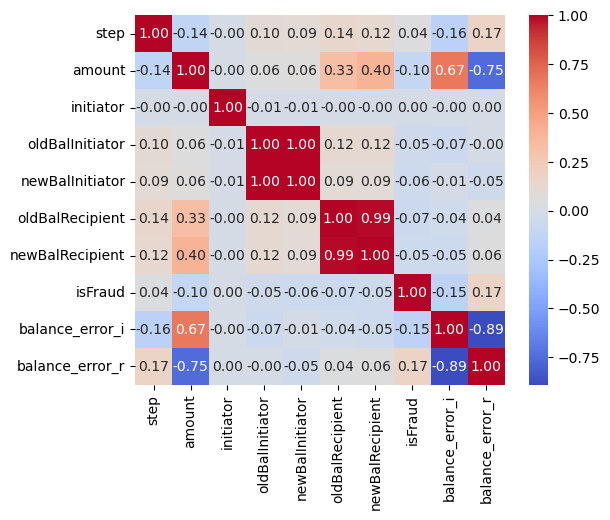

In [34]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True) , annot=True , fmt='.2f' , cmap='coolwarm' , square=True)
plt.show()

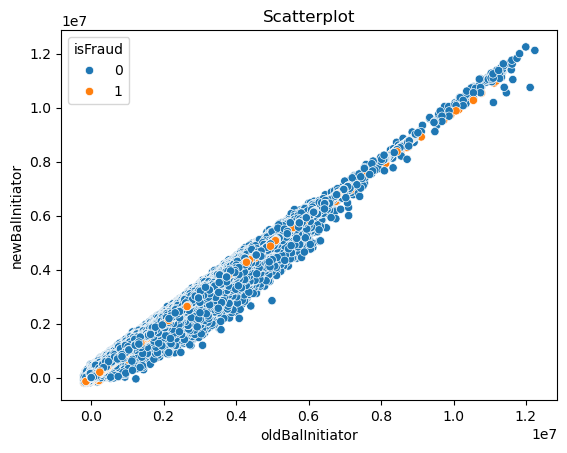

In [35]:
plt.figure()
sns.scatterplot(data=df , x='oldBalInitiator' , y='newBalInitiator' , hue='isFraud')
plt.title('Scatterplot')
plt.show()

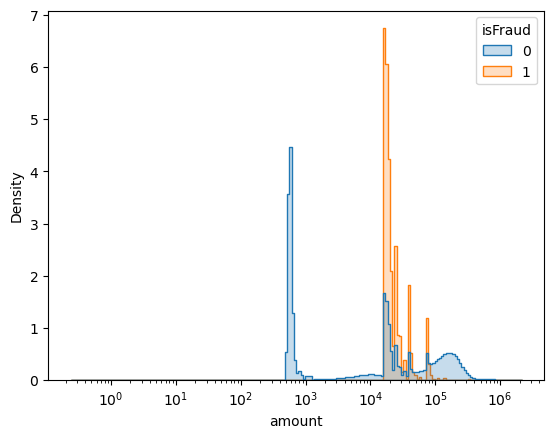

In [36]:
plt.figure()
sns.histplot(data=df , x='amount' , hue='isFraud' , log_scale=True , stat='density' , common_norm=False , element='step')
plt.show()

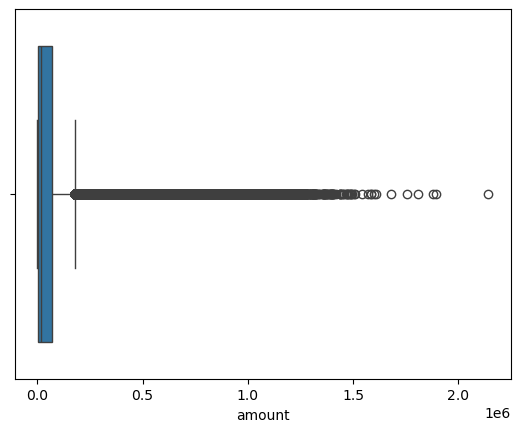

In [39]:
plt.figure()
sns.boxplot(data=df , x='amount')
plt.show()